# Multifractional Brownian Motion (mBm)

## 1. From Constant to Time-Varying Hurst

**Fractional Brownian Motion** has a fixed $H$ everywhere. **Multifractional Brownian Motion** relaxes this:

$$\boxed{H \;\to\; H(t)}$$

It is a centered Gaussian process with covariance:

$$\mathrm{Cov}\bigl(X_t, X_s\bigr) \;=\; \frac{1}{2}\Bigl(t^{H(t)+H(s)} + s^{H(t)+H(s)} - |t-s|^{H(t)+H(s)}\Bigr)$$

When $H(t) \equiv H$, this reduces exactly to fBm.

### What changes?

| Feature | fBm ($H$ constant) | mBm ($H(t)$ varying) |
|---------|-------------------|----------------------|
| **Local regularity** | Uniform $H$-Hölder | $H(t)$-Hölder at each point |
| **Spectrum** | Global power law | Local, time-dependent power law |
| **Quadratic variation** | Deterministic, vanishes if $H>0.5$ | Depends on $H(t)$ locally |
| **Long memory** | Fixed persistence | Persistence varies with time |

## 2. Simulation

Because $H(t)$ is deterministic, the covariance matrix is fixed. **One Cholesky decomposition** generates all sample paths — no per-path overhead.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
from scipy.ndimage import uniform_filter1d
import os

np.random.seed(42)

SAVE_DIR = './mbm_output'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


In [11]:
# Cell 2: mBm Covariance and Generator (FIXED)

def mbm_covariance(t, H_func):
    """
    Covariance matrix for multifractional Brownian motion.
    H_func: callable H(t) or array of H values at times t.
    """
    t = np.asarray(t)
    H = np.asarray(H_func(t)) if callable(H_func) else np.asarray(H_func)
    H_t = H[:, None]
    H_s = H[None, :]
    sum_H = H_t + H_s
    return 0.5 * (t[:, None]**sum_H + t[None, :]**sum_H - np.abs(t[:, None] - t[None, :])**sum_H)


def generate_mbm(t, H_func, n_paths=1):
    """
    Generate mBm paths with robust positive-definite enforcement.
    """
    n = len(t)
    C = mbm_covariance(t, H_func)
    C = (C + C.T) / 2  # enforce exact symmetry
    
    # Try Cholesky with moderate jitter first
    try:
        L = cholesky(C + 1e-9 * np.eye(n), lower=True)
    except np.linalg.LinAlgError:
        # Fallback: eigenvalue clipping (guaranteed PSD)
        eigvals, eigvecs = np.linalg.eigh(C)
        eigvals = np.maximum(eigvals, 1e-9)
        C_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
        L = cholesky(C_psd, lower=True)
    
    Z = np.random.randn(n, n_paths)
    return L @ Z


## 3. Visualizing $H(t)$ Functions

We compare four regimes:
- **Constant** $H=0.5$ (standard BM)
- **Linear** drift from rough ($H=0.3$) to smooth ($H=0.8$)
- **Sinusoidal** periodic roughness
- **Step** abrupt change in regularity

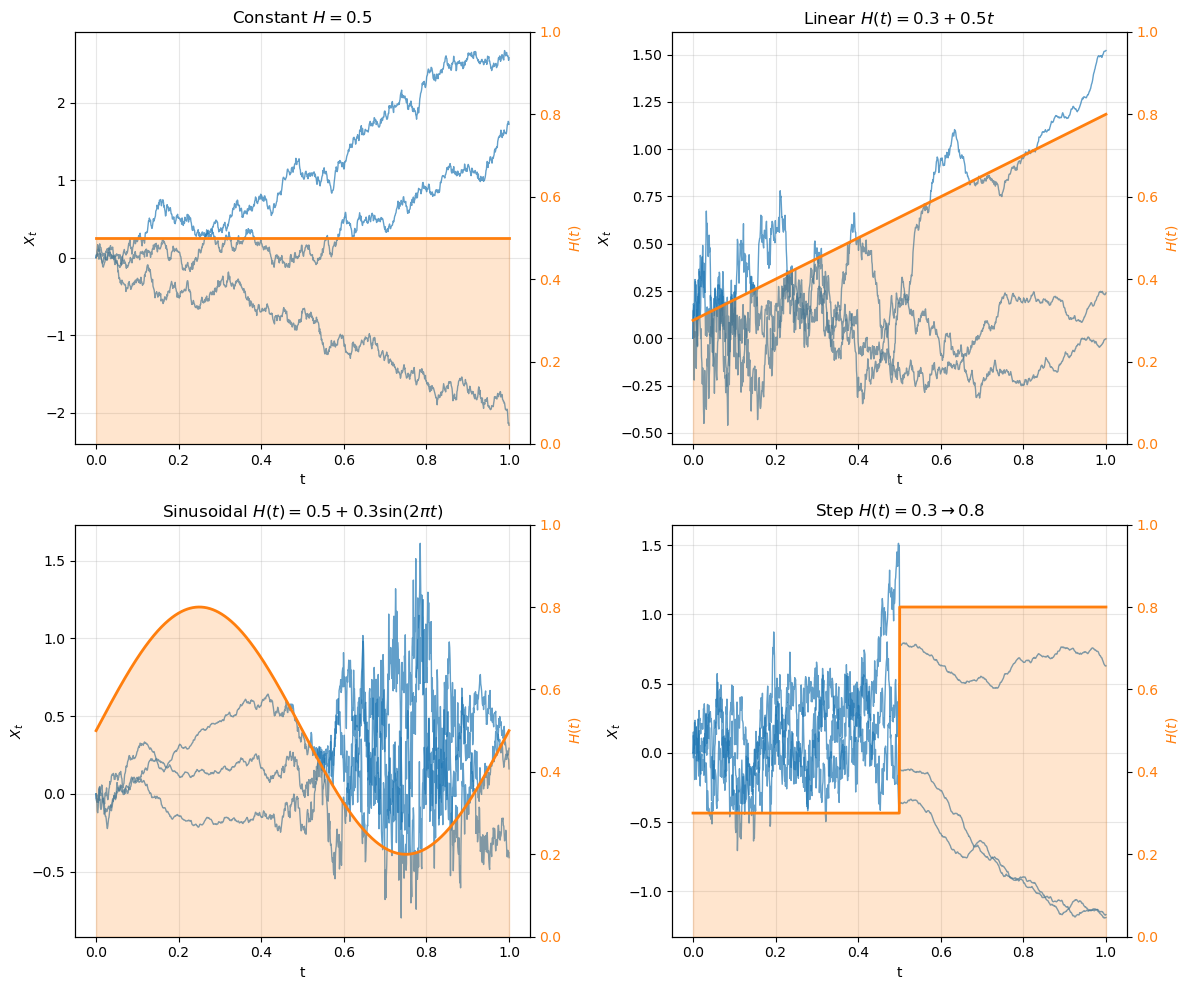

In [12]:
# Sample Paths for Different H(t)

n = 1024
T = 1.0
t = np.linspace(0, T, n)

H_const  = lambda t: np.full_like(t, 0.5)
H_linear = lambda t: 0.3 + 0.5 * (t / T)
H_sine   = lambda t: 0.5 + 0.3 * np.sin(2 * np.pi * t / T)
H_step   = lambda t: np.where(t < T / 2, 0.3, 0.8)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

H_funcs = [
    (H_const,  r'Constant $H = 0.5$'),
    (H_linear, r'Linear $H(t) = 0.3 + 0.5t$'),
    (H_sine,   r'Sinusoidal $H(t) = 0.5 + 0.3\sin(2\pi t)$'),
    (H_step,   r'Step $H(t) = 0.3 \to 0.8$')
]

for ax, (Hf, title) in zip(axes.flat, H_funcs):
    # Plot H(t) on secondary axis
    H_vals = Hf(t)
    ax_H = ax.twinx()
    ax_H.fill_between(t, H_vals, alpha=0.2, color='tab:orange')
    ax_H.plot(t, H_vals, color='tab:orange', linewidth=2)
    ax_H.set_ylabel(r'$H(t)$', color='tab:orange')
    ax_H.tick_params(axis='y', labelcolor='tab:orange')
    ax_H.set_ylim(0, 1)
    
    # Generate and plot 3 mBm paths
    X = generate_mbm(t, Hf, n_paths=3)
    for j in range(3):
        ax.plot(t, X[:, j], alpha=0.7, linewidth=1.0, color='tab:blue')
    
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.set_ylabel(r'$X_t$')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mbm_sample_paths.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Local Roughness Tracks $H(t)$

For fBm, $\mathbb{E}[|X_{t+\Delta t} - X_t|^2] \sim (\Delta t)^{2H}$. For mBm, this holds locally:

$$\mathbb{E}[|X_{t+\Delta t} - X_t|^2] \;\sim\; (\Delta t)^{2H(t)} \quad \text{as } \Delta t \to 0$$

**Consequence:** when $H(t)$ is small, the path is locally rougher (larger increments). We can visualize this by plotting smoothed absolute increments alongside $H(t)$.


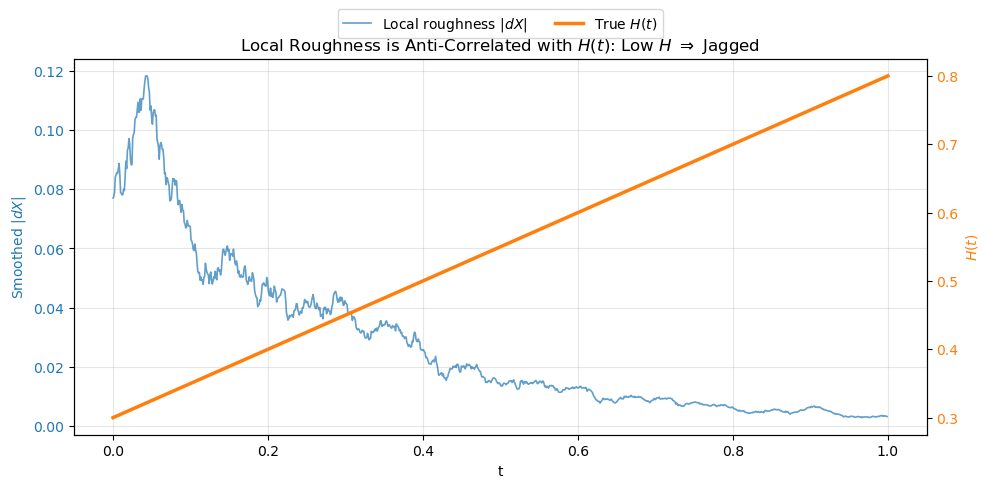

In [6]:
# Local Roughness vs H(t)

H_true_func = lambda t: 0.3 + 0.5 * (t / T)
X = generate_mbm(t, H_true_func, n_paths=1)[:, 0]

dX = np.diff(X)
local_roughness = uniform_filter1d(np.abs(dX), size=32)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.plot(t[:-1], local_roughness, color=color, alpha=0.7, linewidth=1.2, label='Local roughness $|dX|$')
ax1.set_xlabel('t')
ax1.set_ylabel('Smoothed $|dX|$', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.plot(t, H_true_func(t), color=color, linewidth=2.5, label=r'True $H(t)$')
ax2.set_ylabel(r'$H(t)$', color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_title(r'Local Roughness is Anti-Correlated with $H(t)$: Low $H$ $\Rightarrow$ Jagged')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mbm_roughness.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Local Hurst Estimation via Sliding-Window Wavelets

To recover $H(t)$ from a single observed path, we use a **sliding window**:

1. Extract a segment $[t - w/2, t + w/2]$
2. Apply wavelet log-moment regression on that segment
3. Move the window and repeat

This gives a local estimate $\hat{H}(t)$. The window size controls the **bias-variance tradeoff**.


In [7]:
# Wavelet Tools (minimal, self-contained)

DB2_LO = np.array([0.482962913145, 0.836516303738,
                   0.224143868042, -0.129409522551])
DB2_HI = np.array([-0.129409522551, -0.224143868042,
                    0.836516303738, -0.482962913145])


def circular_convolve(x, h):
    N = len(x)
    Xf = np.fft.fft(x)
    Hf = np.fft.fft(h, n=N)
    return np.fft.ifft(Xf * Hf).real


def dwt_level(x, h_lo, h_hi):
    a = circular_convolve(x, h_lo)[::2]
    d = circular_convolve(x, h_hi)[::2]
    return a, d


def wavedec_details(x, h_lo, h_hi, max_level=None):
    if max_level is None:
        max_level = int(np.floor(np.log2(len(x))))
    details = []
    a = np.asarray(x, dtype=float)
    for j in range(max_level):
        if len(a) < len(h_lo):
            break
        a, d = dwt_level(a, h_lo, h_hi)
        details.append(d)
    return details, a


def estimate_hurst_wavelet(x, min_scale=2, max_scale=5):
    """Global wavelet Hurst estimate for a single path."""
    details, _ = wavedec_details(x, DB2_LO, DB2_HI)
    J = len(details)
    max_scale = min(max_scale, J - 1)
    scales = []
    log_moments = []
    for j in range(min_scale - 1, max_scale):
        d = details[j]
        moment = np.mean(d**2)
        if moment > 0:
            scales.append(j + 1)
            log_moments.append(np.log2(moment))
    scales = np.array(scales, dtype=float)
    log_moments = np.array(log_moments)
    slope, _ = np.polyfit(scales, log_moments, 1)
    return (slope - 1.0) / 2.0


def local_hurst_estimate(t, x, window_size=128, step=8, min_scale=2, max_scale=4):
    """
    Sliding-window wavelet Hurst estimation.
    Returns window centers and H estimates.
    """
    n = len(x)
    centers = []
    H_local = []
    half = window_size // 2
    
    for center in range(half, n - half, step):
        segment = x[center - half:center + half]
        valid_len = 2**int(np.floor(np.log2(len(segment))))
        if valid_len < 2**max_scale * 2:
            continue
        segment = segment[:valid_len]
        try:
            H_est = estimate_hurst_wavelet(segment, min_scale=min_scale, max_scale=max_scale)
            if 0.05 < H_est < 0.95:
                centers.append(t[center])
                H_local.append(H_est)
        except Exception:
            continue
    return np.array(centers), np.array(H_local)


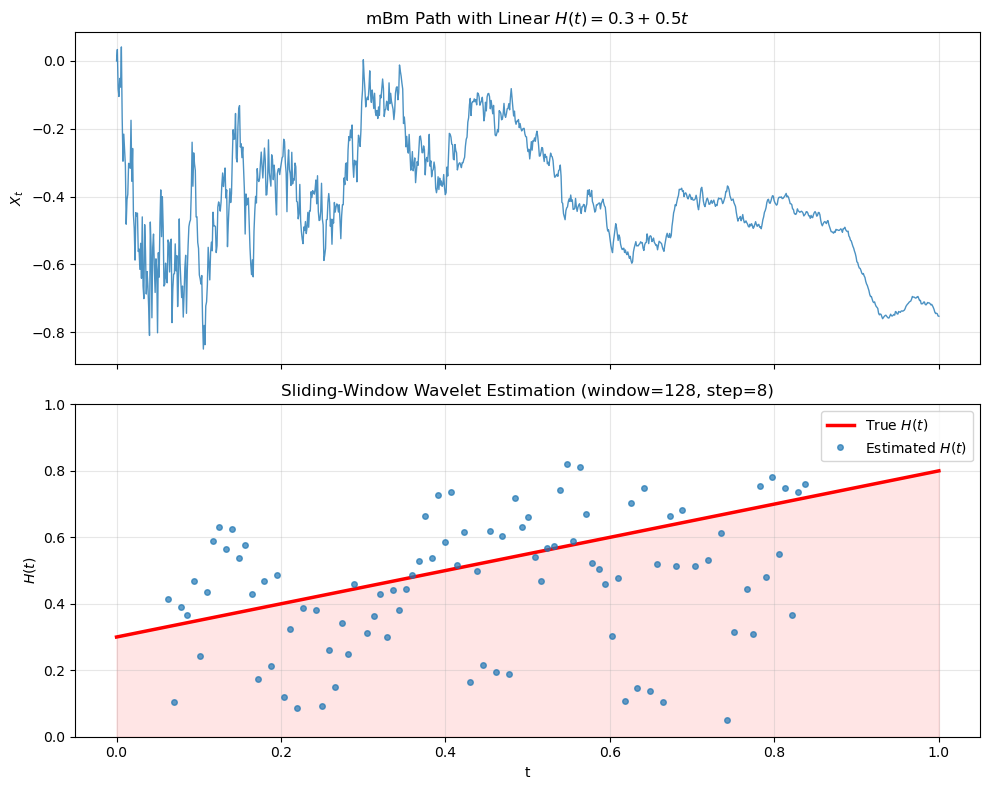

In [8]:
# Recover H(t) from a Single Path

# Test on linear H(t)
centers, H_est = local_hurst_estimate(t, X, window_size=128, step=8, min_scale=2, max_scale=4)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Path
ax = axes[0]
ax.plot(t, X, color='tab:blue', linewidth=1.0, alpha=0.8)
ax.set_ylabel(r'$X_t$')
ax.set_title(r'mBm Path with Linear $H(t) = 0.3 + 0.5t$')
ax.grid(True, alpha=0.3)

# H(t) comparison
ax = axes[1]
ax.plot(t, H_true_func(t), 'r-', linewidth=2.5, label='True $H(t)$')
ax.plot(centers, H_est, 'o', color='tab:blue', markersize=4, alpha=0.7, label='Estimated $H(t)$')
ax.fill_between(t, H_true_func(t), alpha=0.1, color='red')
ax.set_xlabel('t')
ax.set_ylabel(r'$H(t)$')
ax.set_title('Sliding-Window Wavelet Estimation (window=128, step=8)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mbm_local_hurst.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Step Change: Detecting Regime Switches

A step function in $H(t)$ is the hardest case. The wavelet estimator smooths the jump due to finite window size — this reveals the **bias-variance tradeoff** explicitly.


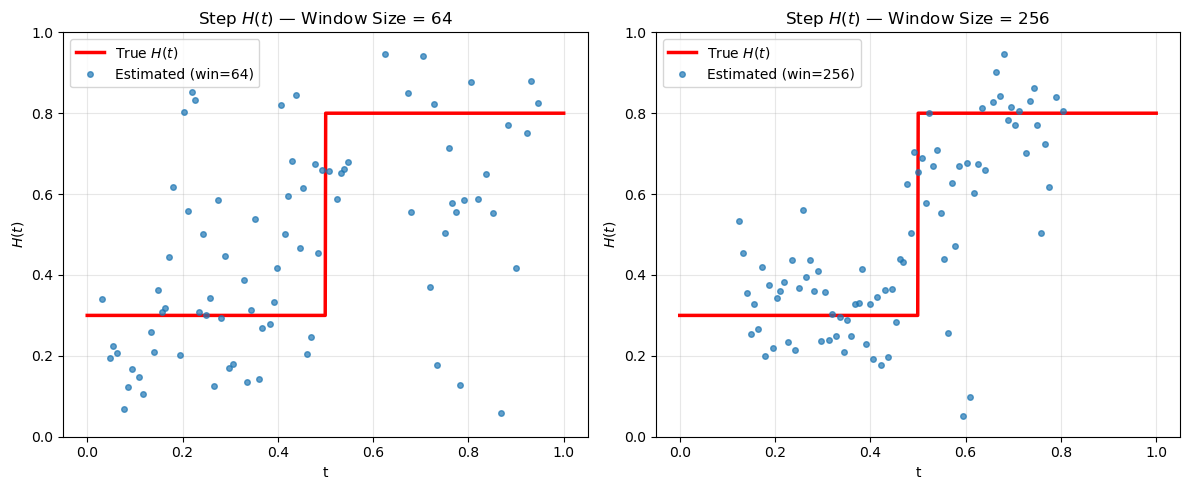

In [13]:
# Step H(t) — Window Size Tradeoff

H_step_func = lambda t: np.where(t < T / 2, 0.3, 0.8)
X_step = generate_mbm(t, H_step_func, n_paths=1)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, wsize in enumerate([64, 256]):
    centers_s, H_est_s = local_hurst_estimate(
        t, X_step, window_size=wsize, step=8, min_scale=2, max_scale=4
    )
    ax = axes[idx]
    ax.plot(t, H_step_func(t), 'r-', linewidth=2.5, label='True $H(t)$')
    ax.plot(centers_s, H_est_s, 'o', color='tab:blue', markersize=4, alpha=0.7,
            label=rf'Estimated (win={wsize})')
    ax.set_title(rf'Step $H(t)$ — Window Size = {wsize}')
    ax.set_xlabel('t')
    ax.set_ylabel(r'$H(t)$')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mbm_step_tradeoff.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. mBm vs Piecewise fBm

A common mistake is to model a process with time-varying $H$ as **piecewise fBm** (concatenating independent fBm segments). This creates **discontinuities** at the junctions. mBm is globally continuous with smoothly varying local regularity.

Below: we compare a true mBm with a concatenation of independent fBm segments.


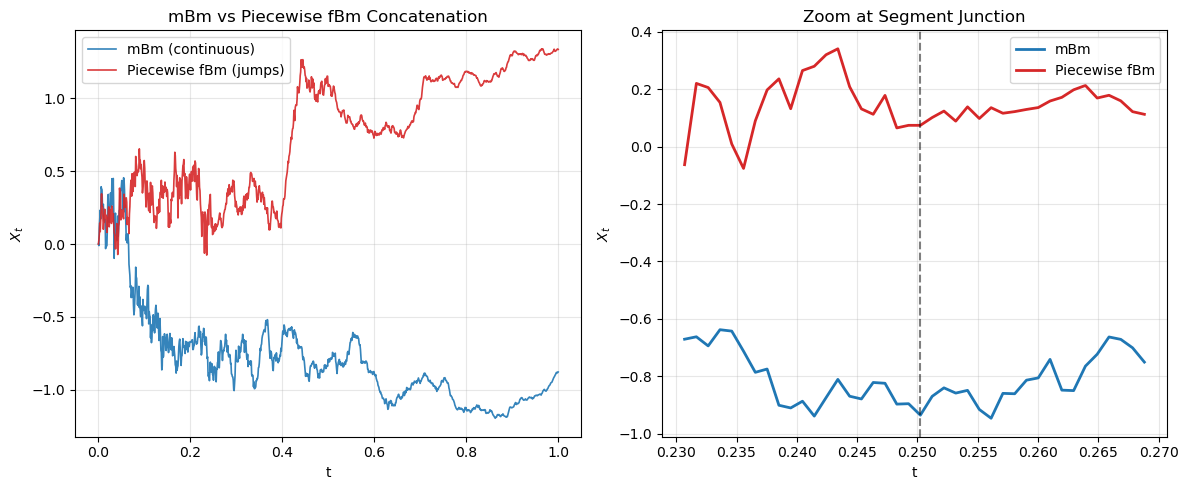

In [14]:
# Cell 8: mBm vs Piecewise fBm Concatenation (FIXED)

# True mBm with linear H(t)
X_mbm = generate_mbm(t, H_linear, n_paths=1)[:, 0]

# Piecewise fBm: 4 independent segments with different H
n_seg = 4
seg_len = n // n_seg
X_piece = np.zeros(n)

for k in range(n_seg):
    H_seg = 0.3 + 0.5 * ((k + 0.5) / n_seg)
    t_seg = np.linspace(0, T / n_seg, seg_len)
    
    # Inline fBm covariance (no external dependency)
    ts = np.asarray(t_seg)
    s = ts[:, None]
    tr = ts[None, :]
    C_seg = 0.5 * (s**(2*H_seg) + tr**(2*H_seg) - np.abs(s - tr)**(2*H_seg))
    C_seg = (C_seg + C_seg.T) / 2
    
    L_seg = cholesky(C_seg + 1e-12 * np.eye(seg_len), lower=True)
    z_seg = np.random.randn(seg_len)
    seg = L_seg @ z_seg
    
    if k > 0:
        seg = seg - seg[0] + X_piece[k * seg_len - 1]
    X_piece[k * seg_len:(k + 1) * seg_len] = seg

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(t, X_mbm, color='tab:blue', linewidth=1.2, alpha=0.9, label='mBm (continuous)')
ax.plot(t, X_piece, color='tab:red', linewidth=1.2, alpha=0.9, label='Piecewise fBm (jumps)')
ax.set_title('mBm vs Piecewise fBm Concatenation')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
junction = seg_len
zoom = slice(junction - 20, junction + 20)
ax.plot(t[zoom], X_mbm[zoom], color='tab:blue', linewidth=2, label='mBm')
ax.plot(t[zoom], X_piece[zoom], color='tab:red', linewidth=2, label='Piecewise fBm')
ax.axvline(t[junction], color='black', linestyle='--', alpha=0.5)
ax.set_title('Zoom at Segment Junction')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mbm_vs_piecewise.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Summary

| Property | fBm | mBm |
|----------|-----|-----|
| **Hurst exponent** | $H \in (0,1)$ constant | $H(t) \in (0,1)$ deterministic function |
| **Covariance** | $\frac{1}{2}(t^{2H} + s^{2H} - |t-s|^{2H})$ | $\frac{1}{2}(t^{H(t)+H(s)} + s^{H(t)+H(s)} - |t-s|^{H(t)+H(s)})$ |
| **Local regularity** | Uniform | Varies as $H(t)$ |
| **Long memory** | Global | Local, time-dependent |
| **Simulation** | One Cholesky per $H$ | One Cholesky per $H(t)$ function |
| **Estimation** | Global wavelet/R/S | Sliding-window wavelet |

### Key Takeaways
1. **mBm is not just "fBm with changing parameters."** It is a single continuous Gaussian process whose local Hölder exponent at time $t$ is exactly $H(t)$.
2. **Simulation is cheap:** because $H(t)$ is deterministic, one Cholesky factorization generates arbitrarily many paths.
3. **Local estimation requires windows.** The window size controls resolution: small windows track fast changes but are noisy; large windows are stable but smear out jumps.
4. **Do not concatenate independent fBm segments.** This destroys continuity and creates spurious jumps that are not present in true mBm.